###Import Libraries

In [46]:
#Used for handling tabular data
import pandas as pd

In [47]:
#Used for numerical operations
import numpy as np

In [48]:
#Used for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
#Used to split data into training and testing
from sklearn.model_selection import train_test_split

In [50]:
#Used for scaling numerical values
from sklearn.preprocessing import StandardScaler

In [51]:
#Machine Learning algorithm
from sklearn.linear_model import LogisticRegression

In [52]:
#Used for evaluation model performance
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

###Load Dataset

In [53]:
#Load Dataset
df = pd.read_csv("/content/creditcard.csv")

In [54]:
#Display first five rows
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


###Check Dataset Information

In [55]:
#Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [56]:
#Check missing values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [57]:
#Impute missing values by median
df = df.fillna(df.median())

###Analyse Fraud and Normal Transactions

In [58]:
#Count normal and fraud transactions
df["Class"].value_counts()

,count
Class,
0,284315
1,492


###Seperate Normal and Fraud Data

In [59]:
#Seperate normal transactions
legit = df[df.Class == 0]

#Seperate fraud transactions
fraud = df[df.Class == 1]

In [60]:
#Display shapes
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


###Compare Transaction Amounts

In [61]:
#Compare Transaction Amounts
print(legit.Amount.describe())
print(fraud.Amount.describe())

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


###Visualze Fraude vs Normal Transactions

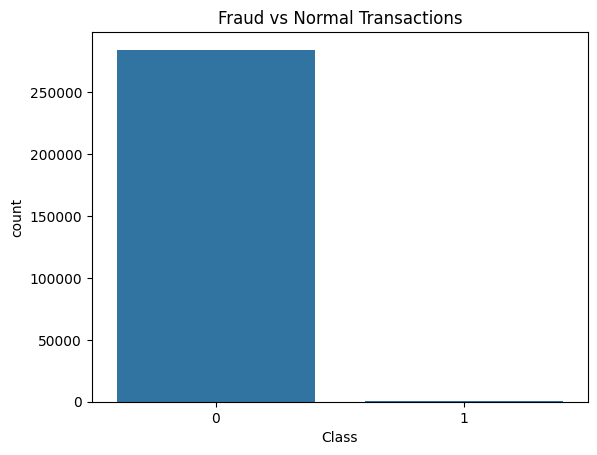

In [62]:
#Plot class distribution
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

###Prepare Data for Training

In [63]:
#Drop target column
X = df.drop(columns="Class", axis=1)

#Target variable
Y = df["Class"]

###Scale the Data

In [64]:
#Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

###Split Data

In [65]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y,
                            test_size = 0.2,
                            stratify = Y,
                            random_state = 7)

###Train the Model

In [66]:
#Create model
model = LogisticRegression()

#Train midel
model.fit(X_train, Y_train)

LogisticRegression()

###Model Evaluation

In [68]:
#Prediction on training data
X_train_prediction = model.predict(X_train)

#Training accuracy
training_accuracy = accuracy_score(X_train_prediction, Y_train)

print("Training Accuracy : ", training_accuracy)

Training Accuracy :  0.999188044503939


#Test Accuracy

In [69]:
#Prediction on test data
X_test_prediction = model.predict(X_test)

#Test accuracy
test_accuracy = accuracy_score(X_test_prediction, Y_test)

print("Test Accuracy : ", test_accuracy)

Test Accuracy :  0.9991748885221726


###Classification Report

In [70]:
#Classification Report
print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.58      0.71        98

    accuracy                           1.00     56962
   macro avg       0.95      0.79      0.85     56962
weighted avg       1.00      1.00      1.00     56962



###Confusion Matrix

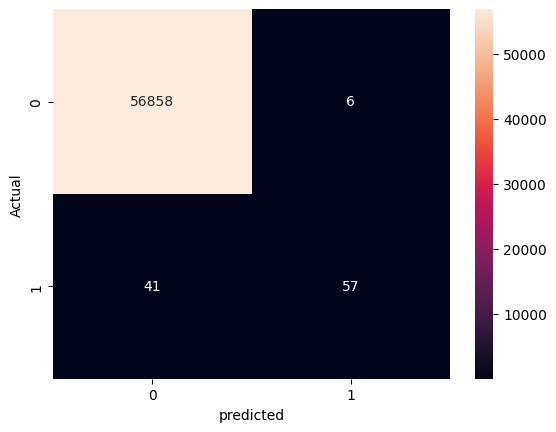

In [72]:
#Confusion matrix
cm = confusion_matrix(Y_test, X_test_prediction)

#Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.show()

###Predict New Transaction

In [74]:
#Example transacion
input_data = X_test[0]

#Reshape data
input_data_reshaped = input_data.reshape(1, -1)

#Prediction
prediction = model.predict(input_data_reshaped)

print(prediction)

if prediction[0] == 0:
  print("Normal Transaction")
else:
  print("Fraud Transaction")

[0]
Normal Transaction
